In [34]:
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
import sys

print(sys.executable)

c:\CodeAlpha\CodeAlpha_EDA\.venv\Scripts\python.exe


In [11]:
# Exploratory Data Analysis — Book Dataset

## Questions Before Analysis

#Before analyzing the dataset, I want to answer the following questions:

#1. Which book categories are most common in the dataset?
#2. What is the average price of books?
#3. Which rating is most common among the books?
#4. Which categories have the highest average book price?
#5. Are higher-rated books generally more expensive?
#6. Are there any missing values, duplicate records, or unusual values in the dataset?

In [12]:
import pandas as pd

df = pd.read_csv("../data/books_dataset.csv")

df.head()

,title,price,rating,availability,category,url
0,A Light in the Attic,51.77,Three,In stock,Poetry,https://books.toscrape.com/catalogue/a-light-i...
1,Tipping the Velvet,53.74,One,In stock,Historical Fiction,https://books.toscrape.com/catalogue/tipping-t...
2,Soumission,50.10,One,In stock,Fiction,https://books.toscrape.com/catalogue/soumissio...
3,Sharp Objects,47.82,Four,In stock,Mystery,https://books.toscrape.com/catalogue/sharp-obj...
4,Sapiens: A Brief History of Humankind,54.23,Five,In stock,History,https://books.toscrape.com/catalogue/sapiens-a...


In [13]:
df.shape

(1000, 6)

In [14]:
df.columns

Index(['title', 'price', 'rating', 'availability', 'category', 'url'], dtype='str')

In [15]:
df.dtypes

title               str
price           float64
rating              str
availability        str
category            str
url                 str
dtype: object

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         1000 non-null   str    
 1   price         1000 non-null   float64
 2   rating        1000 non-null   str    
 3   availability  1000 non-null   str    
 4   category      1000 non-null   str    
 5   url           1000 non-null   str    
dtypes: float64(1), str(5)
memory usage: 47.0 KB


In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.describe()

,price
count,1000.00000
mean,35.07035
std,14.44669
min,10.00000
25%,22.10750
50%,35.98000
75%,47.45750
max,59.99000


In [19]:
df["rating"].value_counts()

rating
One      226
Three    203
Five     196
Two      196
Four     179
Name: count, dtype: int64

In [20]:
df["category"].value_counts()

category
Default               152
Nonfiction            110
Sequential Art         75
Add a comment          67
Fiction                65
Young Adult            54
Fantasy                48
Romance                35
Mystery                32
Food and Drink         30
Childrens              29
Historical Fiction     26
Poetry                 19
Classics               19
History                18
Horror                 17
Womens Fiction         17
Science Fiction        16
Science                14
Music                  13
Business               12
Travel                 11
Thriller               11
Philosophy             11
Humor                  10
Autobiography           9
Art                     8
Religion                7
Psychology              7
Spirituality            6
New Adult               6
Christian Fiction       6
Self Help               5
Biography               5
Sports and Games        5
Health                  4
Politics                3
Contemporary            3
Chr

In [21]:
df.isnull().sum()

title           0
price           0
rating          0
availability    0
category        0
url             0
dtype: int64

In [22]:
df[df["category"] == "Add a comment"][["title", "category"]].head(10)

,title,category
55,The Torch Is Passed: A Harding Family Story,Add a comment
63,The Mindfulness and Acceptance Workbook for An...,Add a comment
70,The Art Forger,Add a comment
88,On a Midnight Clear,Add a comment
97,Judo: Seven Steps to Black Belt (an Introducto...,Add a comment
170,"Shobu Samurai, Project Aryoku (#3)",Add a comment
180,Modern Romance,Add a comment
232,The White Queen (The Cousins' War #1),Add a comment
238,The Song of Achilles,Add a comment
247,The Immortal Life of Henrietta Lacks,Add a comment


In [23]:
count = (df["category"] == "Add a comment").sum()

percentage = (count / len(df)) * 100

print("Suspicious records:", count)
print("Percentage:", round(percentage, 2), "%")

Suspicious records: 67
Percentage: 6.7 %


In [24]:
df["url"].nunique()

1000

In [25]:
df["availability"].value_counts()

availability
In stock    1000
Name: count, dtype: int64

In [26]:
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df["rating_numeric"] = df["rating"].map(rating_map)

df[["rating", "rating_numeric"]].head()

,rating,rating_numeric
0,Three,3
1,One,1
2,One,1
3,Four,4
4,Five,5


In [27]:
df.groupby("rating_numeric")["price"].mean()

rating_numeric
1    34.561195
2    34.810918
3    34.692020
4    36.093296
5    35.374490
Name: price, dtype: float64

In [29]:
df["rating_numeric"].corr(df["price"], method="spearman")

np.float64(0.02921568643020118)

In [30]:
category_avg_price = (
    df.groupby("category")["price"]
    .mean()
    .sort_values(ascending=False)
)

category_avg_price.head(10)

category
Suspense            58.330000
Novels              54.810000
Politics            53.613333
Health              51.452500
New Adult           46.383333
Christian           42.496667
Sports and Games    41.166000
Self Help           40.620000
Travel              39.794545
Fantasy             39.593958
Name: price, dtype: float64

In [31]:
category_summary = df.groupby("category").agg(
    book_count=("title", "count"),
    average_price=("price", "mean")
).sort_values("average_price", ascending=False)

category_summary.head(10)

,book_count,average_price
category,,
Suspense,1,58.330000
Novels,1,54.810000
Politics,3,53.613333
Health,4,51.452500
New Adult,6,46.383333
Christian,3,42.496667
Sports and Games,5,41.166000
Self Help,5,40.620000
Travel,11,39.794545


In [32]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)

Q1: 22.1075
Q3: 47.457499999999996
IQR: 25.349999999999994
Lower limit: -15.91749999999999
Upper limit: 85.48249999999999


In [33]:
outliers = df[
    (df["price"] < lower_limit) |
    (df["price"] > upper_limit)
]

print("Number of price outliers:", len(outliers))

Number of price outliers: 0


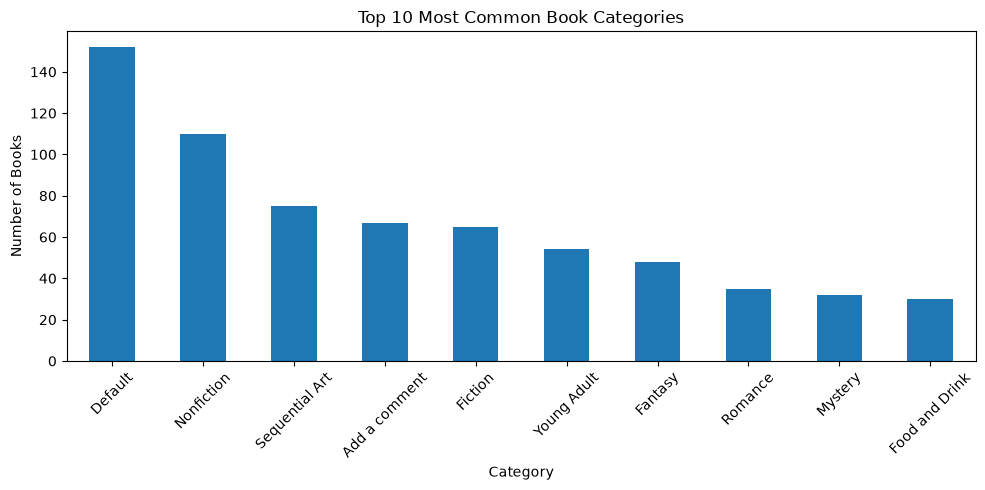

In [35]:
top_categories = df["category"].value_counts().head(10)

top_categories.plot(
    kind="bar",
    figsize=(10, 5),
    title="Top 10 Most Common Book Categories"
)

plt.xlabel("Category")
plt.ylabel("Number of Books")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

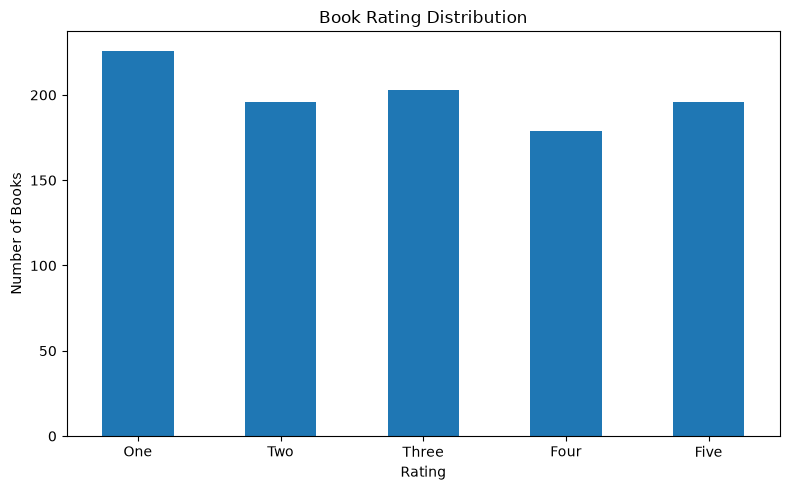

In [36]:
rating_counts = df["rating"].value_counts()

rating_counts = rating_counts.reindex(
    ["One", "Two", "Three", "Four", "Five"]
)

rating_counts.plot(
    kind="bar",
    figsize=(8, 5),
    title="Book Rating Distribution"
)

plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

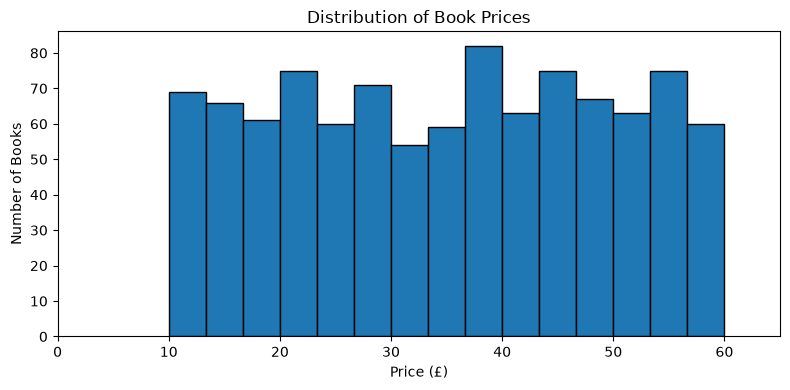

In [38]:
plt.figure(figsize=(8, 4))

plt.hist(
    df["price"],
    bins=15,
    edgecolor="black"
)

plt.title("Distribution of Book Prices")
plt.xlabel("Price (£)")
plt.ylabel("Number of Books")

plt.xlim(0, 65)
plt.tight_layout()
plt.show()

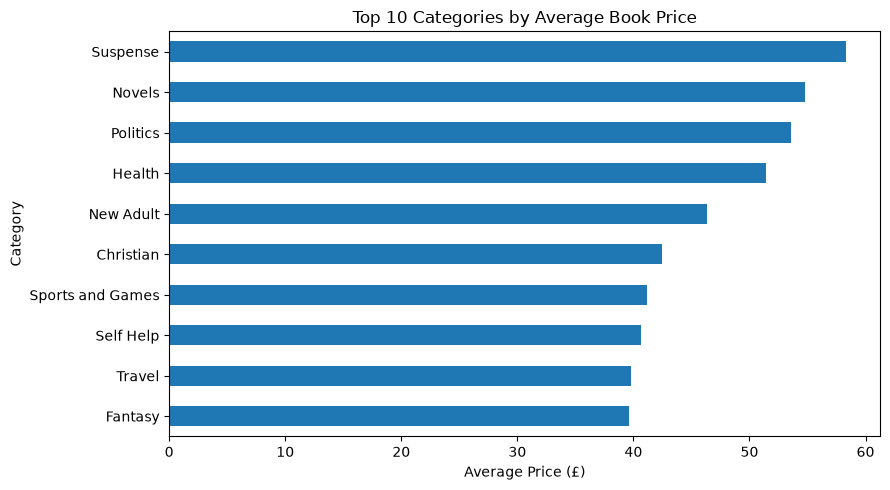

In [39]:
top_price_categories = category_summary.head(10)

top_price_categories["average_price"].sort_values().plot(
    kind="barh",
    figsize=(9, 5),
    title="Top 10 Categories by Average Book Price"
)

plt.xlabel("Average Price (£)")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

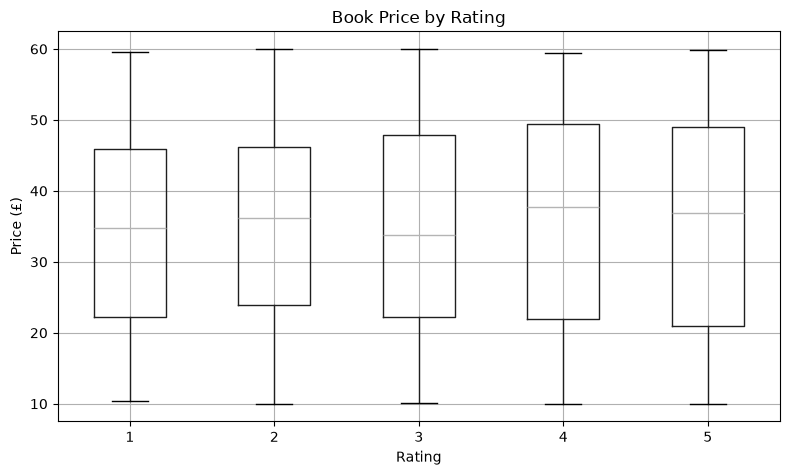

In [40]:
df.boxplot(
    column="price",
    by="rating_numeric",
    figsize=(8, 5)
)

plt.title("Book Price by Rating")
plt.suptitle("")
plt.xlabel("Rating")
plt.ylabel("Price (£)")
plt.tight_layout()
plt.show()

## Key Findings

- The dataset contains 1,000 books and 6 original variables.
- There are no missing values in the dataset.
- No duplicate records were found.
- All 1,000 product URLs are unique.
- All books were listed as "In stock".
- The average book price is £35.07, while the median price is £35.98.
- The most common rating is 1 star, with 226 books.
- There are 50 different book categories.
- "Default" is the most common category, containing 152 books.
- No price outliers were detected using the IQR method.
- Some categories have high average prices but very few books, so their averages should be interpreted carefully.
- The "Add a comment" category appears in 67 records, representing 6.7% of the dataset, and should be investigated as a potential data-quality issue.

## Hypothesis Testing

### Hypothesis

Higher-rated books are generally more expensive.

### Result

The hypothesis is **not supported by the dataset**.

The Spearman correlation between rating and price is approximately **0.0292**, indicating an extremely weak relationship between the two variables.

The average prices for different ratings are also very similar:

- 1 star: £34.56
- 2 stars: £34.81
- 3 stars: £34.69
- 4 stars: £36.09
- 5 stars: £35.37

The boxplot also shows considerable overlap in book prices across different ratings.

Therefore, in this dataset, a higher rating does not appear to be associated with a meaningfully higher price.

## Data Quality Issues

The following potential data-quality issues were identified:

1. **Suspicious category:** "Add a comment" appears as a category for 67 records (6.7%). This should be investigated because it may represent incorrectly scraped category information.
2. **Uneven category sizes:** Some categories contain only one or a few books. Therefore, their average prices may not be representative.
3. **Limited availability variation:** All books are marked as "In stock", so availability cannot be meaningfully analyzed.
4. **No missing or duplicate records:** No missing values or duplicate rows were detected.
5. **No price outliers:** The IQR method identified no unusual price values.

## Overall Conclusion

The EDA shows that the dataset contains 1,000 books with complete records and no duplicate rows. Book prices range from £10.00 to £59.99, with an average price of £35.07.

The analysis found differences in average prices across categories, but categories with very small sample sizes should be interpreted cautiously. Rating and price have almost no relationship, so higher-rated books are not necessarily more expensive.

The main data-quality concern is the presence of the "Add a comment" category in 67 records. This issue should be reviewed before using the dataset for further analysis or modeling.